<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/02_ML_16_customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning.

# Clustering

### Amaliyot: Mijozlarni klasterlash

In [52]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

#### Dataset

In [53]:
url="https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/customer_segmentation.csv"
df = pd.read_csv(url)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2


In [54]:
df.shape

(850, 10)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 66.5+ KB


#### Ma'lumotlarni tozalash
`Address` ustuni matnli. Masofa hisoblashda esa bu ustundan foydalan olmaymiz, shuning bu ustunni tashglab yuboramiz.

In [56]:
df.drop('Address', axis=1, inplace=True)
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


**Normalizasiya**

`Customer Id` ustunidan boshqa barcha ustunlarni normalizasiya qilamiz.

In [58]:
from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
norm_data = StandardScaler().fit_transform(X)
norm_data

array([[ 0.74291541,  0.31212243, -0.37878978, ..., -0.59048916,
        -0.52379654, -0.57652509],
       [ 1.48949049, -0.76634938,  2.5737211 , ...,  1.51296181,
        -0.52379654,  0.39138677],
       [-0.25251804,  0.31212243,  0.2117124 , ...,  0.80170393,
         1.90913822,  1.59755385],
       ...,
       [-1.24795149,  2.46906604, -1.26454304, ...,  0.03863257,
         1.90913822,  3.45892281],
       [-0.37694723, -0.76634938,  0.50696349, ..., -0.70147601,
        -0.52379654, -1.08281745],
       [ 2.1116364 , -0.76634938,  1.09746566, ...,  0.16463355,
        -0.52379654, -0.2340332 ]])

### Model
Dataset turli mijozlarning yoshi, ishlagan yillar soni, daromadi, qarzi ka'bi ma'lumotlardan iborat. Maqsadimiz shu ma'lumotlardan foydalangan holda mijozlarni truli klasterlarga ajratish.

### Biz bu mijozlarni 3 ta clasterga ajratamiz

In [59]:
k = 3
k_means = KMeans(n_clusters = k) # init va n_init standart qiymatlarni qabul qiladi, biz faqat klasterlar sonini ko'rsatdik.
k_means.fit(norm_data)
print(k_means.labels_)

[1 2 0 1 2 2 1 1 1 2 0 1 1 1 0 1 1 1 2 1 1 1 0 2 2 1 1 1 1 1 1 2 0 1 1 1 0
 0 1 2 0 2 1 2 1 2 1 1 1 1 2 2 0 1 0 0 0 1 1 1 2 1 2 2 1 1 1 0 1 0 1 1 1 1
 1 1 1 1 2 1 1 0 2 1 2 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 0 2 1 0 0 2 1 1 1 1 1
 1 1 0 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 2 1 1 0
 1 1 1 2 0 1 1 1 1 2 0 0 1 1 1 1 1 1 1 1 1 1 2 1 1 0 1 0 1 1 0 2 0 1 1 2 0
 2 1 1 1 1 1 2 1 0 1 1 1 2 2 1 2 1 0 1 1 0 1 2 1 0 1 1 1 1 1 0 0 2 1 1 0 2
 1 1 1 1 2 1 1 0 1 1 1 1 2 1 1 0 2 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 2 0 1 0 1
 1 1 2 1 0 2 0 1 2 1 1 0 1 1 1 1 0 0 0 1 1 1 2 1 1 2 1 2 1 1 2 1 1 1 0 1 1
 0 1 0 2 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 2 1 0 1 1 1 0 0 1 1 1 2 0
 1 1 0 1 2 1 1 1 1 1 0 2 1 1 1 1 1 2 1 1 1 1 1 2 1 1 1 2 0 1 0 1 1 1 2 2 1
 0 1 2 0 0 1 1 1 0 1 1 1 1 1 2 1 2 1 1 1 1 0 1 0 1 1 1 2 1 1 1 1 0 1 1 0 0
 2 1 1 1 1 1 0 0 1 2 0 2 1 1 0 1 1 2 2 1 0 1 1 2 1 0 1 2 1 1 1 2 1 1 1 1 2
 1 0 1 1 1 1 2 0 1 1 2 1 0 1 1 2 1 2 1 1 1 1 1 1 1 2 2 1 1 2 1 0 1 1 1 0 1
 0 1 1 1 1 1 2 0 0 1 2 1 

In [60]:
k_means.cluster_centers_


array([[-3.90439547e-01,  1.62695612e-01, -6.79376729e-01,
        -3.86448408e-01, -6.83901553e-05, -6.93056978e-02,
         1.87982575e+00,  5.69270845e-01],
       [-1.49558091e-01, -1.14064018e-01, -1.34481828e-01,
        -2.72413651e-01, -3.35659257e-01, -3.69866734e-01,
        -5.23796543e-01, -3.24345859e-01],
       [ 1.00292949e+00,  2.37745062e-01,  1.27767064e+00,
         1.45504409e+00,  1.24780477e+00,  1.45422700e+00,
        -2.04998195e-01,  5.53954880e-01]])

In [61]:
print(np.round(k_means.cluster_centers_))

[[-0.  0. -1. -0. -0. -0.  2.  1.]
 [-0. -0. -0. -0. -0. -0. -1. -0.]
 [ 1.  0.  1.  1.  1.  1. -0.  1.]]


Mijozalr klasterlarga ajratildi. Keling bu ma'lumnotlarni df ga qo'shamiz.

In [62]:
df['cluster'] = k_means.labels_
df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
0,1,41,2,6,19,0.124,1.073,0.0,6.3,1
1,2,47,1,26,100,4.582,8.218,0.0,12.8,2
2,3,33,2,10,57,6.111,5.802,1.0,20.9,0
3,4,29,2,4,19,0.681,0.516,0.0,6.3,1
4,5,47,1,31,253,9.308,8.908,0.0,7.2,2


### Klasterlar haqida nima deya olamiz?
Har bir klaster sentrodini topish orqali kalsterlar haqida ma'lumot olishimiz mumkin. Buning uchun esa `groupby` va `mean` funksiyalaridan foydalanamiz

In [63]:
df.groupby('cluster').mean()

# Bu kod df ma'lumotlar to'plamini 'cluster' ustuni bo'yicha guruhlaydi va keyin har bir klaster
# uchun barcha sonli ustunlarning o'rtacha qiymatini hisoblaydi. Bu har bir klasterdagi
# mijozlarning o'rtacha xususiyatlarini tushunishga yordam beradi.

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
cluster,,,,,,,,,
0,424.451807,31.891566,1.861446,3.963855,31.789157,1.576675,2.843355,0.993939,13.994578
1,425.302412,33.827458,1.604824,7.654917,36.181818,0.863681,1.822410,0.000000,7.993506
2,427.434483,43.089655,1.931034,17.220690,102.724138,4.227897,8.018490,0.165217,13.891724


Har bir klasterdagi mijozlar haqida qanday xulosa qilish mumkin?

Masalan, yoshiga (`Age`) qaraydigan bo'lsak 0-klaster katta yoshlar (43+), 1-klaster o'rta yosh (33+), 2-klaster yoshlar (31 gacha).

Har bir klasterni yaqqol ajratib turuvchi ustunlar bu `Income` (daromad) va `Year Employed` (necha yildan beri ishlashi) ekan.

Demak biz har klasterni quyidagicha ta'riflashimiz mumkin:
- 0-klaster - Katta yosh, uzoq tajribaga ega, katta daromad qiluvchi mijozlar.
- 1-klaster - Yosh, kam tajriba va kam daromad mijozlar.
- 2-klaster - O'rta yosh, 7+ yil tarjibaga ega, kam daromad mijozlar.

Umuman olganda siz aynan sizning biznesingiz uchun muhim ustunlar bo'yicha klasterlarga nom berishingiz mumkin, masalan moliya xizamtini yo'lga qo'ygan bo'lsangiz (muddatli to'lov, kredit) qarzlar (`Debt`) va qarzni qaytarmaganlik (`Deafulted`) ustunlariga ahamiyat bergan bo'lar edim.

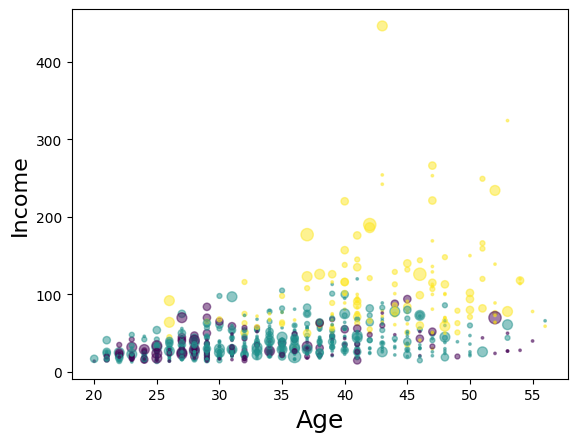

In [64]:
area = np.pi * ( X[:, 1])**2
# Har bir nuqtaning hajmini Edu (ta'lim darajasi) ustuniga asoslanib hisoblaydi.

plt.scatter(X[:, 0], X[:, 3], s=area, c=k_means.labels_.astype(float), alpha=0.5)
#  Tarqoq diagramma (scatter plot) chizadi. Bunda X[:, 0] yoshni (x-o'qi), X[:, 3] esa daromadni
# (y-o'qi) ifodalaydi. Nuqtalar hajmi area bilan, rangi esa klasterlarga qarab belgilanadi va shaffofligi 0.5 ga teng.

plt.xlabel('Age', fontsize=18)
# x-o'qiga 'Age' (Yosh) belgisini beradi.
plt.ylabel('Income', fontsize=16)
# y-o'qiga 'Income' (Daromad) belgisini beradi.
plt.show()
#  Grafikni ko'rsatadi.

### Bu pastdagi kod mijozlarning Years Employed, Age, va Income ma'lumotlarini 3D fazoda klasterlarga ajratib vizualizatsiya qilish uchun ishlatiladi:

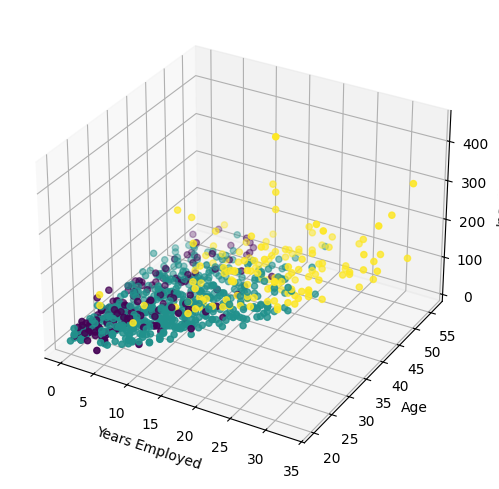

In [65]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# 3D grafiklar uchun zarur bo'lgan kutubxonalarni import qilindi.

# Grafik
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# Yangi grafik oynasini yaratadi va 3D o'qlar tizimini qo'shadi.

ax.set_xlabel('Years Employed')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

# 3D scatter
ax.scatter(X[:, 2], X[:, 0], X[:, 3], c=k_means.labels_.astype(float), cmap='viridis')
#  Asosiy 3D scatter plotni chizadi. Bunda X[:, 2] (Years Employed), X[:, 0] (Age) va X[:, 3] (Income)
# ma'lumotlari nuqtalarning joylashuvini, c=k_means.labels_.astype(float) esa nuqtalarning rangini
# klasterlarga qarab belgilaydi. cmap='viridis' ranglar palitrasini tanlaydi.
plt.show()